# Notebook 8

This is a first try to explore how ABP behaves for the narrow escape problem

In [1]:
import numpy as np
from stage_escape.abp_abf.abp_metadynamics import ABPMetaDynamics
from stage_escape.surface import Surface
from stage_escape.escape import Escape
from stage_escape.abp_abf.abp_equivalent_narrow_escape import ABPEquivalentNarrowEscape
from stage_escape.abp_abf.transition_detector import TransitionDetector
from stage_escape.statistics import Statistics
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

In [4]:
deposition_stride = 10000
DELTA_T = 0.001
DIMENSION = 2
SEED = 42  # Set a seed for reproducibility

Escape time: 43.72082451708075


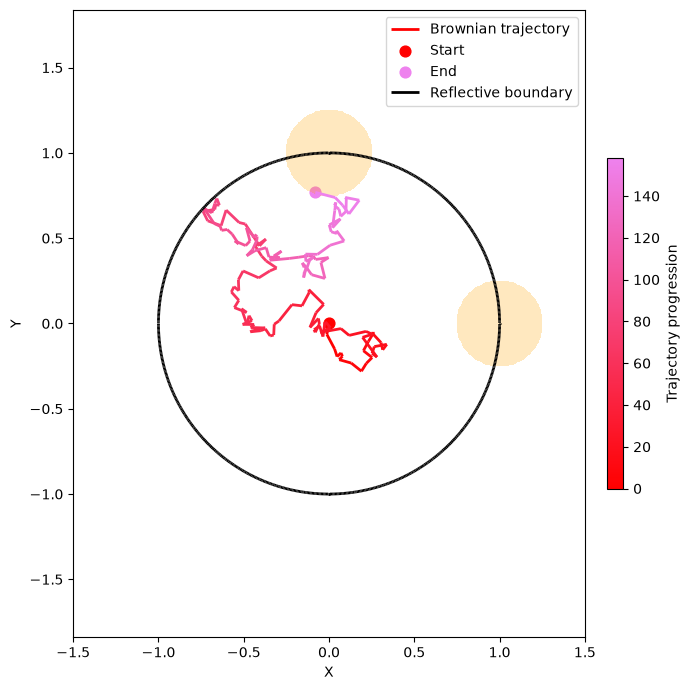

In [11]:

# Surface defined by the equation x^2 + y^2 = 1 (unit circle)
surface = Surface(name='circle', functions=[lambda x: x[0]**2 + x[1]**2 - 1])

point1 = np.array([1, 0])
escape1 = Escape([lambda x: np.sum(np.abs(x - point1) ** 2) <= (0.5 / 2) ** 2]) # Escape region

point2 = np.array([0, 1])
escape2 = Escape([lambda x: np.sum(np.abs(x - point2) ** 2) <= (0.5 / 2) ** 2])

def cv(x):
    if escape1.conditions[0](x) or escape2.conditions[0](x):
        return 1
    return -1

td = TransitionDetector(np.array([]), cv=cv, threshold=0)

abp = ABPMetaDynamics(deposition_stride=5, td=td, delta_t=DELTA_T, dimension=DIMENSION, W=1, D=1, sigma=0.2)

narrow_escape = ABPEquivalentNarrowEscape(abp, surface, [escape1, escape2])

escape_point, escape_time = narrow_escape.run_simulation()
print(f'Escape time: {escape_time}')
narrow_escape.plot_narrow_escape_problem()


In [12]:
def run_one_simulation_2d(deltat):
    # Surface defined by the equation x^2 + y^2 = 1 (unit circle)
    surface = Surface(name='circle', functions=[lambda x: x[0]**2 + x[1]**2 - 1])

    point1 = np.array([1, 0])
    escape1 = Escape([lambda x: np.sum(np.abs(x - point1) ** 2) <= (0.5 / 2) ** 2]) # Escape region

    point2 = np.array([-1, 0])
    escape2 = Escape([lambda x: np.sum(np.abs(x - point2) ** 2) <= (0.5 / 2) ** 2])

    def cv(x):
        if escape1.conditions[0](x) or escape2.conditions[0](x):
            return 1
        return -1

    td = TransitionDetector(np.array([]), cv=cv, threshold=0)

    abp = ABPMetaDynamics(deposition_stride=10, td=td, delta_t=deltat, dimension=DIMENSION, W=1, D=1, sigma=0.2)

    narrow_escape = ABPEquivalentNarrowEscape(abp, surface, [escape1, escape2])

    escape_point, escape_time = narrow_escape.run_simulation()
    return escape_point, escape_time

Sizes:   0%|          | 0/20 [00:00<?, ?it/s]

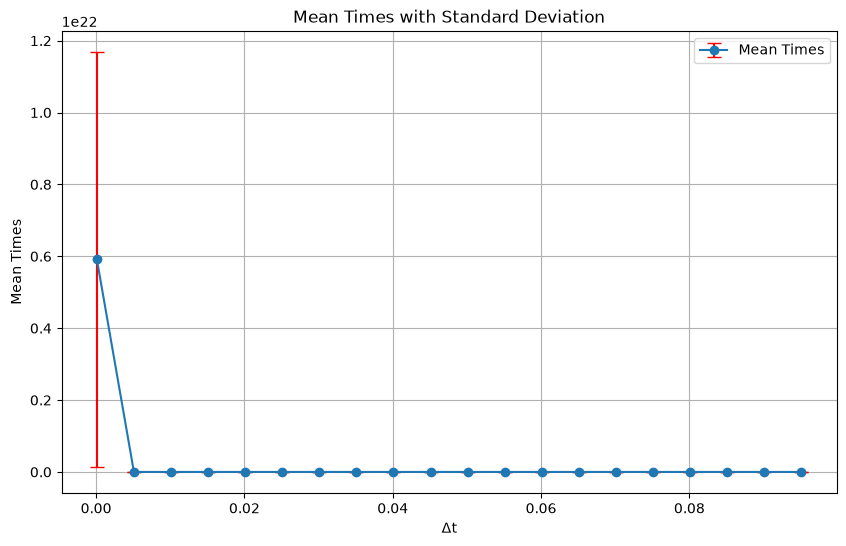

In [14]:
x_axis = np.arange(0.0001, 0.1, 0.005)
mean_escape_times = []
dev_escape_times = []

# Equal epsilon
for deltat in tqdm(x_axis, desc="Sizes"):
    escape_times = []
    exit_points = []

    
    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation_2d)(deltat)
        for _ in range(20)
    )

    for escape_point, escape_time in results:
        if escape_point is not None:
            escape_times.append(escape_time)
            exit_points.append(escape_point)

    escape_times = np.array(escape_times)
    exit_points = np.array(exit_points)

    mean_escape_time = np.mean(escape_times)
    mean_escape_times.append(mean_escape_time)

    dev_escape_time = np.std(escape_times)
    dev_escape_times.append(dev_escape_time / np.sqrt(len(escape_times)))  # Standard error of the mean

Statistics.plot_mean_times(x_axis, mean_escape_times, dev_escape_times, xlabel='Δt')

In [ ]:
def run_one_simulation_2d(deltat):
    # Surface defined by the equation x^2 + y^2 = 1 (unit circle)
    surface = Surface(name='circle', functions=[lambda x: x[0]**2 + x[1]**2 - 1])

    point1 = np.array([1, 0])
    escape1 = Escape([lambda x: np.sum(np.abs(x - point1) ** 2) <= (0.5 / 2) ** 2]) # Escape region

    point2 = np.array([-1, 0])
    escape2 = Escape([lambda x: np.sum(np.abs(x - point2) ** 2) <= (0.5 / 2) ** 2])

    def cv(x):
        if escape1.conditions[0](x) or escape2.conditions[0](x):
            return 1
        return -1

    td = TransitionDetector(np.array([]), cv=cv, threshold=0)

    abp = ABPMetaDynamics(deposition_stride=10, td=td, delta_t=deltat, dimension=DIMENSION, W=1, D=1, sigma=0.2)

    narrow_escape = ABPEquivalentNarrowEscape(abp, surface, [escape1, escape2])

    escape_point, escape_time = narrow_escape.run_simulation()
    return escape_point, escape_time

Sizes:   0%|          | 0/19 [00:00<?, ?it/s]

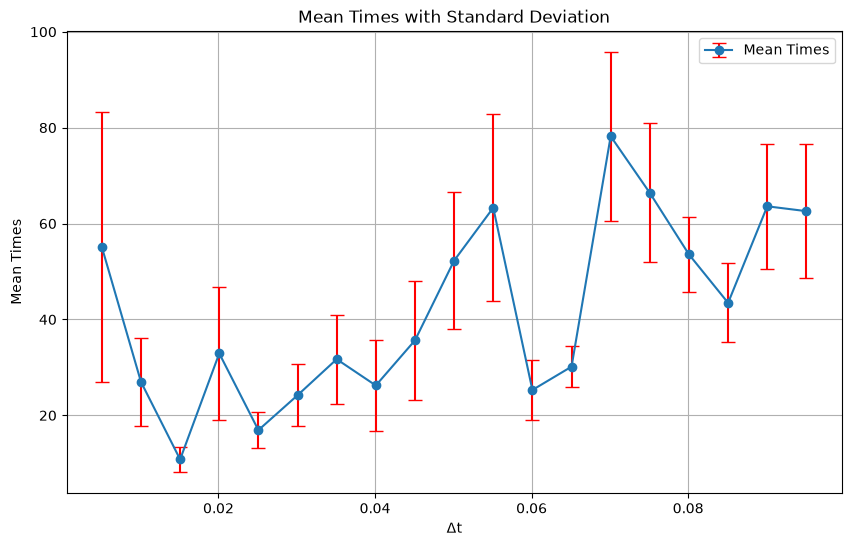

In [ ]:
x_axis = np.arange(0.0051, 0.1, 0.005)
mean_escape_times = []
dev_escape_times = []

# Equal epsilon
for deltat in tqdm(x_axis, desc="Sizes"):
    escape_times = []
    exit_points = []

    
    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation_2d)(deltat)
        for _ in range(30)
    )

    for escape_point, escape_time in results:
        if escape_point is not None:
            escape_times.append(escape_time)
            exit_points.append(escape_point)

    escape_times = np.array(escape_times)
    exit_points = np.array(exit_points)

    mean_escape_time = np.mean(escape_times)
    mean_escape_times.append(mean_escape_time)

    dev_escape_time = np.std(escape_times)
    dev_escape_times.append(dev_escape_time / np.sqrt(len(escape_times)))  # Standard error of the mean

Statistics.plot_mean_times(x_axis, mean_escape_times, dev_escape_times, xlabel='Δt')

In [ ]:
def run_one_simulation_2d(deltat):
    # Surface defined by the equation x^2 + y^2 = 1 (unit circle)
    surface = Surface(name='circle', functions=[lambda x: x[0]**2 + x[1]**2 - 1])

    point1 = np.array([1, 0])
    escape1 = Escape([lambda x: np.sum(np.abs(x - point1) ** 2) <= (0.5 / 2) ** 2]) # Escape region

    point2 = np.array([-1, 0])
    escape2 = Escape([lambda x: np.sum(np.abs(x - point2) ** 2) <= (0.5 / 2) ** 2])

    def cv(x):
        if escape1.conditions[0](x) or escape2.conditions[0](x):
            return 1
        return -1

    td = TransitionDetector(np.array([]), cv=cv, threshold=0)

    abp = ABPMetaDynamics(deposition_stride=10, td=td, delta_t=deltat, dimension=DIMENSION, W=1, D=1, sigma=0.2)

    narrow_escape = ABPEquivalentNarrowEscape(abp, surface, [escape1, escape2])

    escape_point, escape_time = narrow_escape.run_simulation()
    return escape_point, escape_time

Sizes:   0%|          | 0/19 [00:00<?, ?it/s]

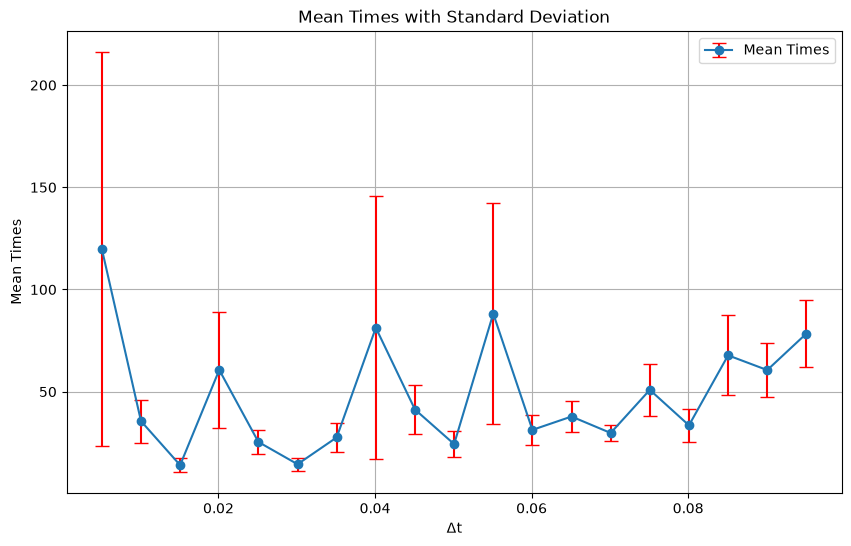

In [ ]:
x_axis = np.arange(0.0051, 0.1, 0.005)
mean_escape_times = []
dev_escape_times = []

# Equal epsilon
for deltat in tqdm(x_axis, desc="Sizes"):
    escape_times = []
    exit_points = []

    
    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation_2d)(deltat)
        for _ in range(30)
    )

    for escape_point, escape_time in results:
        if escape_point is not None:
            escape_times.append(escape_time)
            exit_points.append(escape_point)

    escape_times = np.array(escape_times)
    exit_points = np.array(exit_points)

    mean_escape_time = np.mean(escape_times)
    mean_escape_times.append(mean_escape_time)

    dev_escape_time = np.std(escape_times)
    dev_escape_times.append(dev_escape_time / np.sqrt(len(escape_times)))  # Standard error of the mean

Statistics.plot_mean_times(x_axis, mean_escape_times, dev_escape_times, xlabel='Δt')